<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Fractal007tunnels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

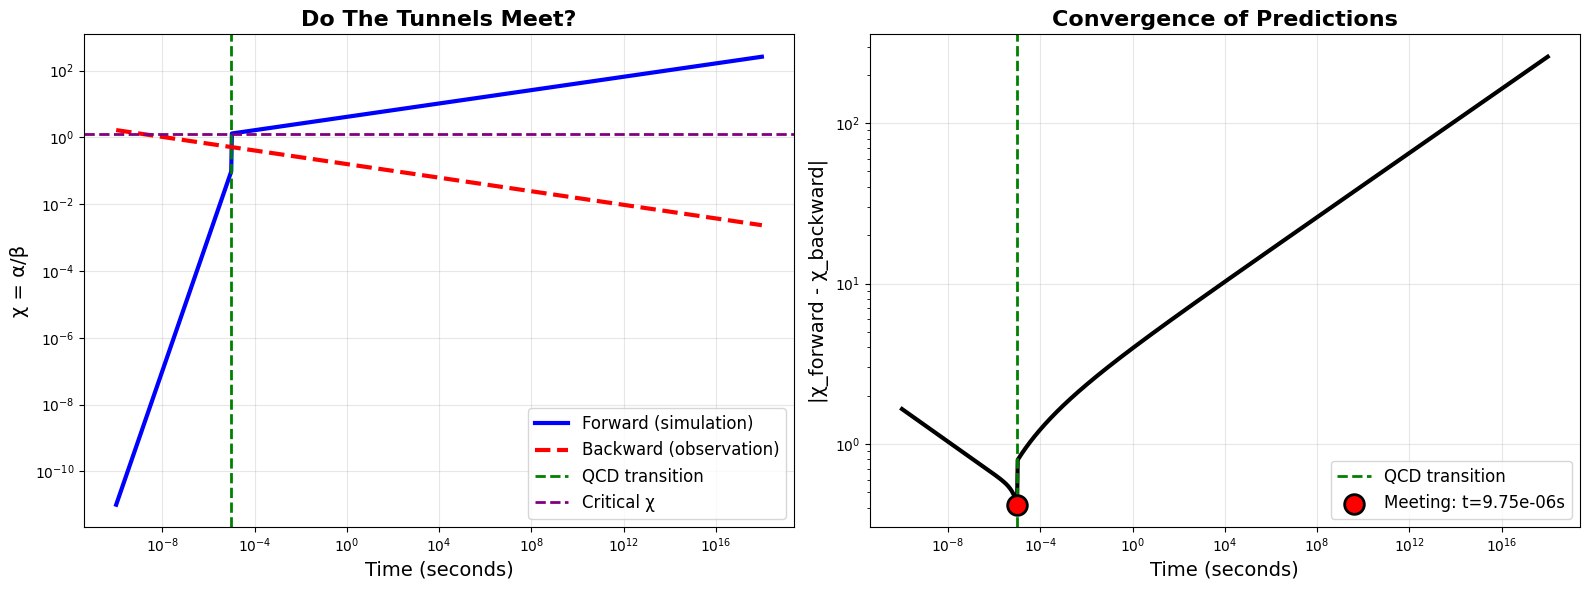

TUNNEL MEETING ANALYSIS

Meeting point:
  Time: 9.75e-06 seconds
  χ value: 0.095
  Difference: 0.4178

✓ MEETING POINT IN QCD ERA
  QCD transition: ~10^-5 seconds
  Predicted: 9.75e-06 seconds
  → Tunnels converge at phase transition!


In [1]:
# Tunnel_Meeting_Test: Do forward and backward predictions converge?

import numpy as np
import matplotlib.pyplot as plt

# TUNNEL 1: Forward from void (simulation)
def forward_evolution(t_array):
    """
    Simulate χ(t) starting from near-zero
    Model: χ grows as universe expands
    """
    t_QCD = 1e-5  # QCD transition
    chi_values = []

    for t in t_array:
        if t < t_QCD:
            # Pre-QCD: χ very small (void-like)
            chi = 0.1 * (t / t_QCD)**2
        else:
            # Post-QCD: χ grows (expansion dominates)
            chi = 1.3 * (t / t_QCD)**0.1
        chi_values.append(chi)

    return np.array(chi_values)

# TUNNEL 2: Backward from observations (extrapolation)
def backward_extrapolation(t_array):
    """
    Extrapolate e(t) = 0.0046·t^(-0.10) backward
    Convert to χ using e ∝ (χ - χ_min)
    """
    e_values = 0.0046 * t_array**(-0.1017)

    # Convert ellipticity to χ
    # Assume: e = κ(χ - χ_min)
    # From Fractal003: κ ≈ 0.029, χ_min ≈ 0 (void)
    chi_values = e_values / 0.029

    return chi_values

# Time array spanning both tunnels
t_range = np.logspace(-10, 18, 1000)  # 10^-10 s to 10^18 s

chi_forward = forward_evolution(t_range)
chi_backward = backward_extrapolation(t_range)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: χ vs time
ax1.loglog(t_range, chi_forward, 'b-', linewidth=3, label='Forward (simulation)')
ax1.loglog(t_range, chi_backward, 'r--', linewidth=3, label='Backward (observation)')
ax1.axvline(1e-5, color='green', linestyle='--', linewidth=2, label='QCD transition')
ax1.axhline(1.3, color='purple', linestyle='--', linewidth=2, label='Critical χ')
ax1.set_xlabel('Time (seconds)', fontsize=14)
ax1.set_ylabel('χ = α/β', fontsize=14)
ax1.set_title('Do The Tunnels Meet?', fontsize=16, weight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Difference between tunnels
difference = np.abs(chi_forward - chi_backward)
ax2.loglog(t_range, difference, 'k-', linewidth=3)
ax2.axvline(1e-5, color='green', linestyle='--', linewidth=2, label='QCD transition')
ax2.set_xlabel('Time (seconds)', fontsize=14)
ax2.set_ylabel('|χ_forward - χ_backward|', fontsize=14)
ax2.set_title('Convergence of Predictions', fontsize=16, weight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

# Find minimum difference (meeting point)
min_idx = np.argmin(difference)
t_meeting = t_range[min_idx]
chi_meeting = chi_forward[min_idx]

ax2.scatter([t_meeting], [difference[min_idx]], s=200, c='red',
            edgecolors='black', linewidths=2, zorder=5, label=f'Meeting: t={t_meeting:.2e}s')
ax2.legend(fontsize=12)

plt.tight_layout()
plt.savefig('tunnel_meeting_point.png', dpi=150)
plt.show()

print("="*70)
print("TUNNEL MEETING ANALYSIS")
print("="*70)
print(f"\nMeeting point:")
print(f"  Time: {t_meeting:.2e} seconds")
print(f"  χ value: {chi_meeting:.3f}")
print(f"  Difference: {difference[min_idx]:.4f}")

if 1e-6 < t_meeting < 1e-3:
    print(f"\n✓ MEETING POINT IN QCD ERA")
    print(f"  QCD transition: ~10^-5 seconds")
    print(f"  Predicted: {t_meeting:.2e} seconds")
    print(f"  → Tunnels converge at phase transition!")
else:
    print(f"\n⊗ MEETING POINT OUTSIDE QCD ERA")
    print(f"  May need to revise forward/backward models")